# EM with IVSCC / skeleton-keys / patch-seq morphological features and MET-type predictions

feature data lives in:
- data/minniephase3-emily_skeleton_keys_features (Emily) (both exc and inh)
- data/EM_exc_mettypes (Matt)
- data/EM_inh_mettypes (Sid) (also contains patchseq)

MET-label estimations are in:
- scratch/h5ad_outputs (Yagmur)
  - scratch/h5ad_outputs/exc_minnie_met_umapknn_wScores.h5ad
  - scratch/h5ad_outputs/exc_minnie_met_umapknn_cellToCell.h5ad
  - scratch/h5ad_outputs/inh_minnie_met_umapknn_wScores.h5ad
  - scratch/h5ad_outputs/inh_minnie_met_umapknn_cellToCell.h5ad

# Load all the data

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from deltalake import DeltaTable

sys.path.insert(0, os.path.abspath('.'))
from utils import get_list_differences

COMBINED = '/root/capsule/scratch/combined_datasets'

# ---------- New CSVs ----------
df_matt_exc    = pd.read_csv('../data/EM_exc_mettypes/EM_RFC_MET_Predictions_FCNormCorrect_And_Uncorrect.csv')
df_sid_inh_em  = pd.read_csv('../data/EM_inh_mettypes/Minnie_Column_Inhibitory_normalized_IVSCC.csv')
df_sid_inh_ps  = pd.read_csv('../data/EM_inh_mettypes/PatchSeq_Inhibitory_normalized_IVSCC.csv')

# ---------- Existing delta tables ----------
df_emily_exc        = DeltaTable(f'{COMBINED}/cellfeatures/minnie_exc_skel_keys').to_pandas()
df_emily_inh        = DeltaTable(f'{COMBINED}/cellfeatures/minnie_inh_skel_keys').to_pandas()
df_dataitems        = DeltaTable(f'{COMBINED}/dataitem').to_pandas()
df_inh_ps_existing  = DeltaTable(f'{COMBINED}/cellfeatures/inh_morph_features').to_pandas()

print("Matt EXC shape:          ", df_matt_exc.shape)
print("Sid INH EM shape:        ", df_sid_inh_em.shape)
print("Sid INH PatchSeq shape:  ", df_sid_inh_ps.shape)
print("Emily EXC (delta) shape: ", df_emily_exc.shape)
print("Emily INH (delta) shape: ", df_emily_inh.shape)
print("dataitem shape:          ", df_dataitems.shape)
print("inh_morph_features shape:", df_inh_ps_existing.shape)


Matt EXC shape:           (38267, 7)
Sid INH EM shape:         (162, 49)
Sid INH PatchSeq shape:   (488, 52)
Emily EXC (delta) shape:  (49714, 58)
Emily INH (delta) shape:  (163, 54)
dataitem shape:           (138597, 4)
inh_morph_features shape: (520, 49)


# Compara the IDs
- EXC: Emily exc to Matt, Emily and Matt to existing minnie dataset in combined datasets
- INH: Emily inh to Sid's EM, Sid's EM to existing minnie
- INH: Sid's patchseq to existing inh patchseq 

## 1A — EXC: Matt ↔ Emily EXC (both minnie65 EM)

In [2]:
matt_ids      = set(df_matt_exc['id'].astype(str))
emily_exc_ids = set(df_emily_exc['id'].astype(str))

print(f"Matt EXC total ids:             {len(matt_ids):>7,}")
print(f"Emily EXC (delta) total ids:    {len(emily_exc_ids):>7,}")
print(f"Intersection (in both):         {len(matt_ids & emily_exc_ids):>7,}")
print(f"Only in Matt  (not in Emily):   {len(matt_ids - emily_exc_ids):>7,}")
print(f"Only in Emily (not in Matt):    {len(emily_exc_ids - matt_ids):>7,}")


Matt EXC total ids:              38,267
Emily EXC (delta) total ids:     49,714
Intersection (in both):          37,056
Only in Matt  (not in Emily):     1,211
Only in Emily (not in Matt):     12,658


## 1B — EXC: Emily EXC + Matt vs `dataitem` (minnie65)

In [3]:
minnie_ids = set(df_dataitems.query("project_id == 'minnie65'")['id'].astype(str))

print(f"Registered minnie65 dataitems:             {len(minnie_ids):>7,}")
print(f"Matt ids NOT in minnie dataitem:           {len(matt_ids - minnie_ids):>7,}")
print(f"Emily EXC ids NOT in minnie dataitem:      {len(emily_exc_ids - minnie_ids):>7,}")


Registered minnie65 dataitems:             133,969
Matt ids NOT in minnie dataitem:                 0
Emily EXC ids NOT in minnie dataitem:            0


## 1C — INH EM: Sid ↔ Emily INH (both minnie65 EM)

In [4]:
sid_inh_em_ids = set(df_sid_inh_em['specimen_id'].astype(str))
emily_inh_ids  = set(df_emily_inh['id'].astype(str))

print(f"Sid INH EM total ids:              {len(sid_inh_em_ids):>5,}")
print(f"Emily INH (delta) total ids:       {len(emily_inh_ids):>5,}")
print(f"Intersection (in both):            {len(sid_inh_em_ids & emily_inh_ids):>5,}")
print(f"Only in Sid EM  (not in Emily):    {len(sid_inh_em_ids - emily_inh_ids):>5,}")
print(f"Only in Emily   (not in Sid EM):   {len(emily_inh_ids - sid_inh_em_ids):>5,}")


Sid INH EM total ids:                162
Emily INH (delta) total ids:         163
Intersection (in both):              162
Only in Sid EM  (not in Emily):        0
Only in Emily   (not in Sid EM):       1


## 1D — INH EM: Sid EM vs `dataitem` (minnie65)

In [5]:
print(f"Sid INH EM ids NOT in minnie dataitem: {len(sid_inh_em_ids - minnie_ids)}")


Sid INH EM ids NOT in minnie dataitem: 0


## 1E — INH PatchSeq: Sid ↔ existing `inh_morph_features`

In [6]:
sid_inh_ps_ids      = set(df_sid_inh_ps['specimen_id'].astype(str))
existing_inh_ps_ids = set(df_inh_ps_existing['id'].astype(str))

print(f"Sid INH PatchSeq total ids:                 {len(sid_inh_ps_ids):>5,}")
print(f"Existing inh_morph_features total ids:      {len(existing_inh_ps_ids):>5,}")
print(f"Intersection (in both):                     {len(sid_inh_ps_ids & existing_inh_ps_ids):>5,}")
print(f"Only in Sid PS  (new cells):                {len(sid_inh_ps_ids - existing_inh_ps_ids):>5,}")
print(f"Only in existing PS (missing from Sid):     {len(existing_inh_ps_ids - sid_inh_ps_ids):>5,}")


Sid INH PatchSeq total ids:                   488
Existing inh_morph_features total ids:        520
Intersection (in both):                       488
Only in Sid PS  (new cells):                    0
Only in existing PS (missing from Sid):        32


# Compare the features
- Matt to Emily exc
- Sid EM to Emily inh
- Sid patchseq to existing patchseq

## 2B — INH EM: Sid EM cols vs Emily INH cols

In [8]:
sid_inh_em_feat_cols  = [c for c in df_sid_inh_em.columns
                          if c not in meta_cols | {'cell_type_pre', 'motif_group'}]
emily_inh_feat_cols   = [c for c in df_emily_inh.columns if c not in meta_cols]

print(f"Sid INH EM feature cols:   {len(sid_inh_em_feat_cols)}")
print(f"Emily INH feature cols:    {len(emily_inh_feat_cols)}")
print()
get_list_differences(sid_inh_em_feat_cols, emily_inh_feat_cols, buf=50)


Sid INH EM feature cols:   46
Emily INH feature cols:    51

ONLY IN A                                          | ONLY IN B                                         
----------------------------------------------------------------------------------------------------
                                                   | basal_dendrite_depth_pc_1                         
                                                   | basal_dendrite_depth_pc_3                         
                                                   | basal_dendrite_depth_pc_0                         
                                                   | basal_dendrite_depth_pc_2                         
                                                   | basal_dendrite_depth_pc_4                         




## 2C — INH PatchSeq: Sid PS cols vs existing `inh_morph_features` cols

In [9]:
label_cols_sid        = {'subtype', 'MET_type', 'T_type', 'T_prob', 'ME_type'}
sid_inh_ps_feat_cols  = [c for c in df_sid_inh_ps.columns
                          if c not in meta_cols | label_cols_sid]
existing_inh_ps_feat_cols = [c for c in df_inh_ps_existing.columns if c not in meta_cols]

print(f"Sid INH PatchSeq feature cols:         {len(sid_inh_ps_feat_cols)}")
print(f"Existing inh_morph_features feat cols: {len(existing_inh_ps_feat_cols)}")
print()
get_list_differences(sid_inh_ps_feat_cols, existing_inh_ps_feat_cols, buf=50)


Sid INH PatchSeq feature cols:         46
Existing inh_morph_features feat cols: 46

ONLY IN A                                          | ONLY IN B                                         
----------------------------------------------------------------------------------------------------




# Compare feature distributions
For features with the same name and same modality, compare empirical distributions.

## 3A — INH EM modality: Sid EM vs Emily INH (shared morpho features)

Shared INH EM features: 46


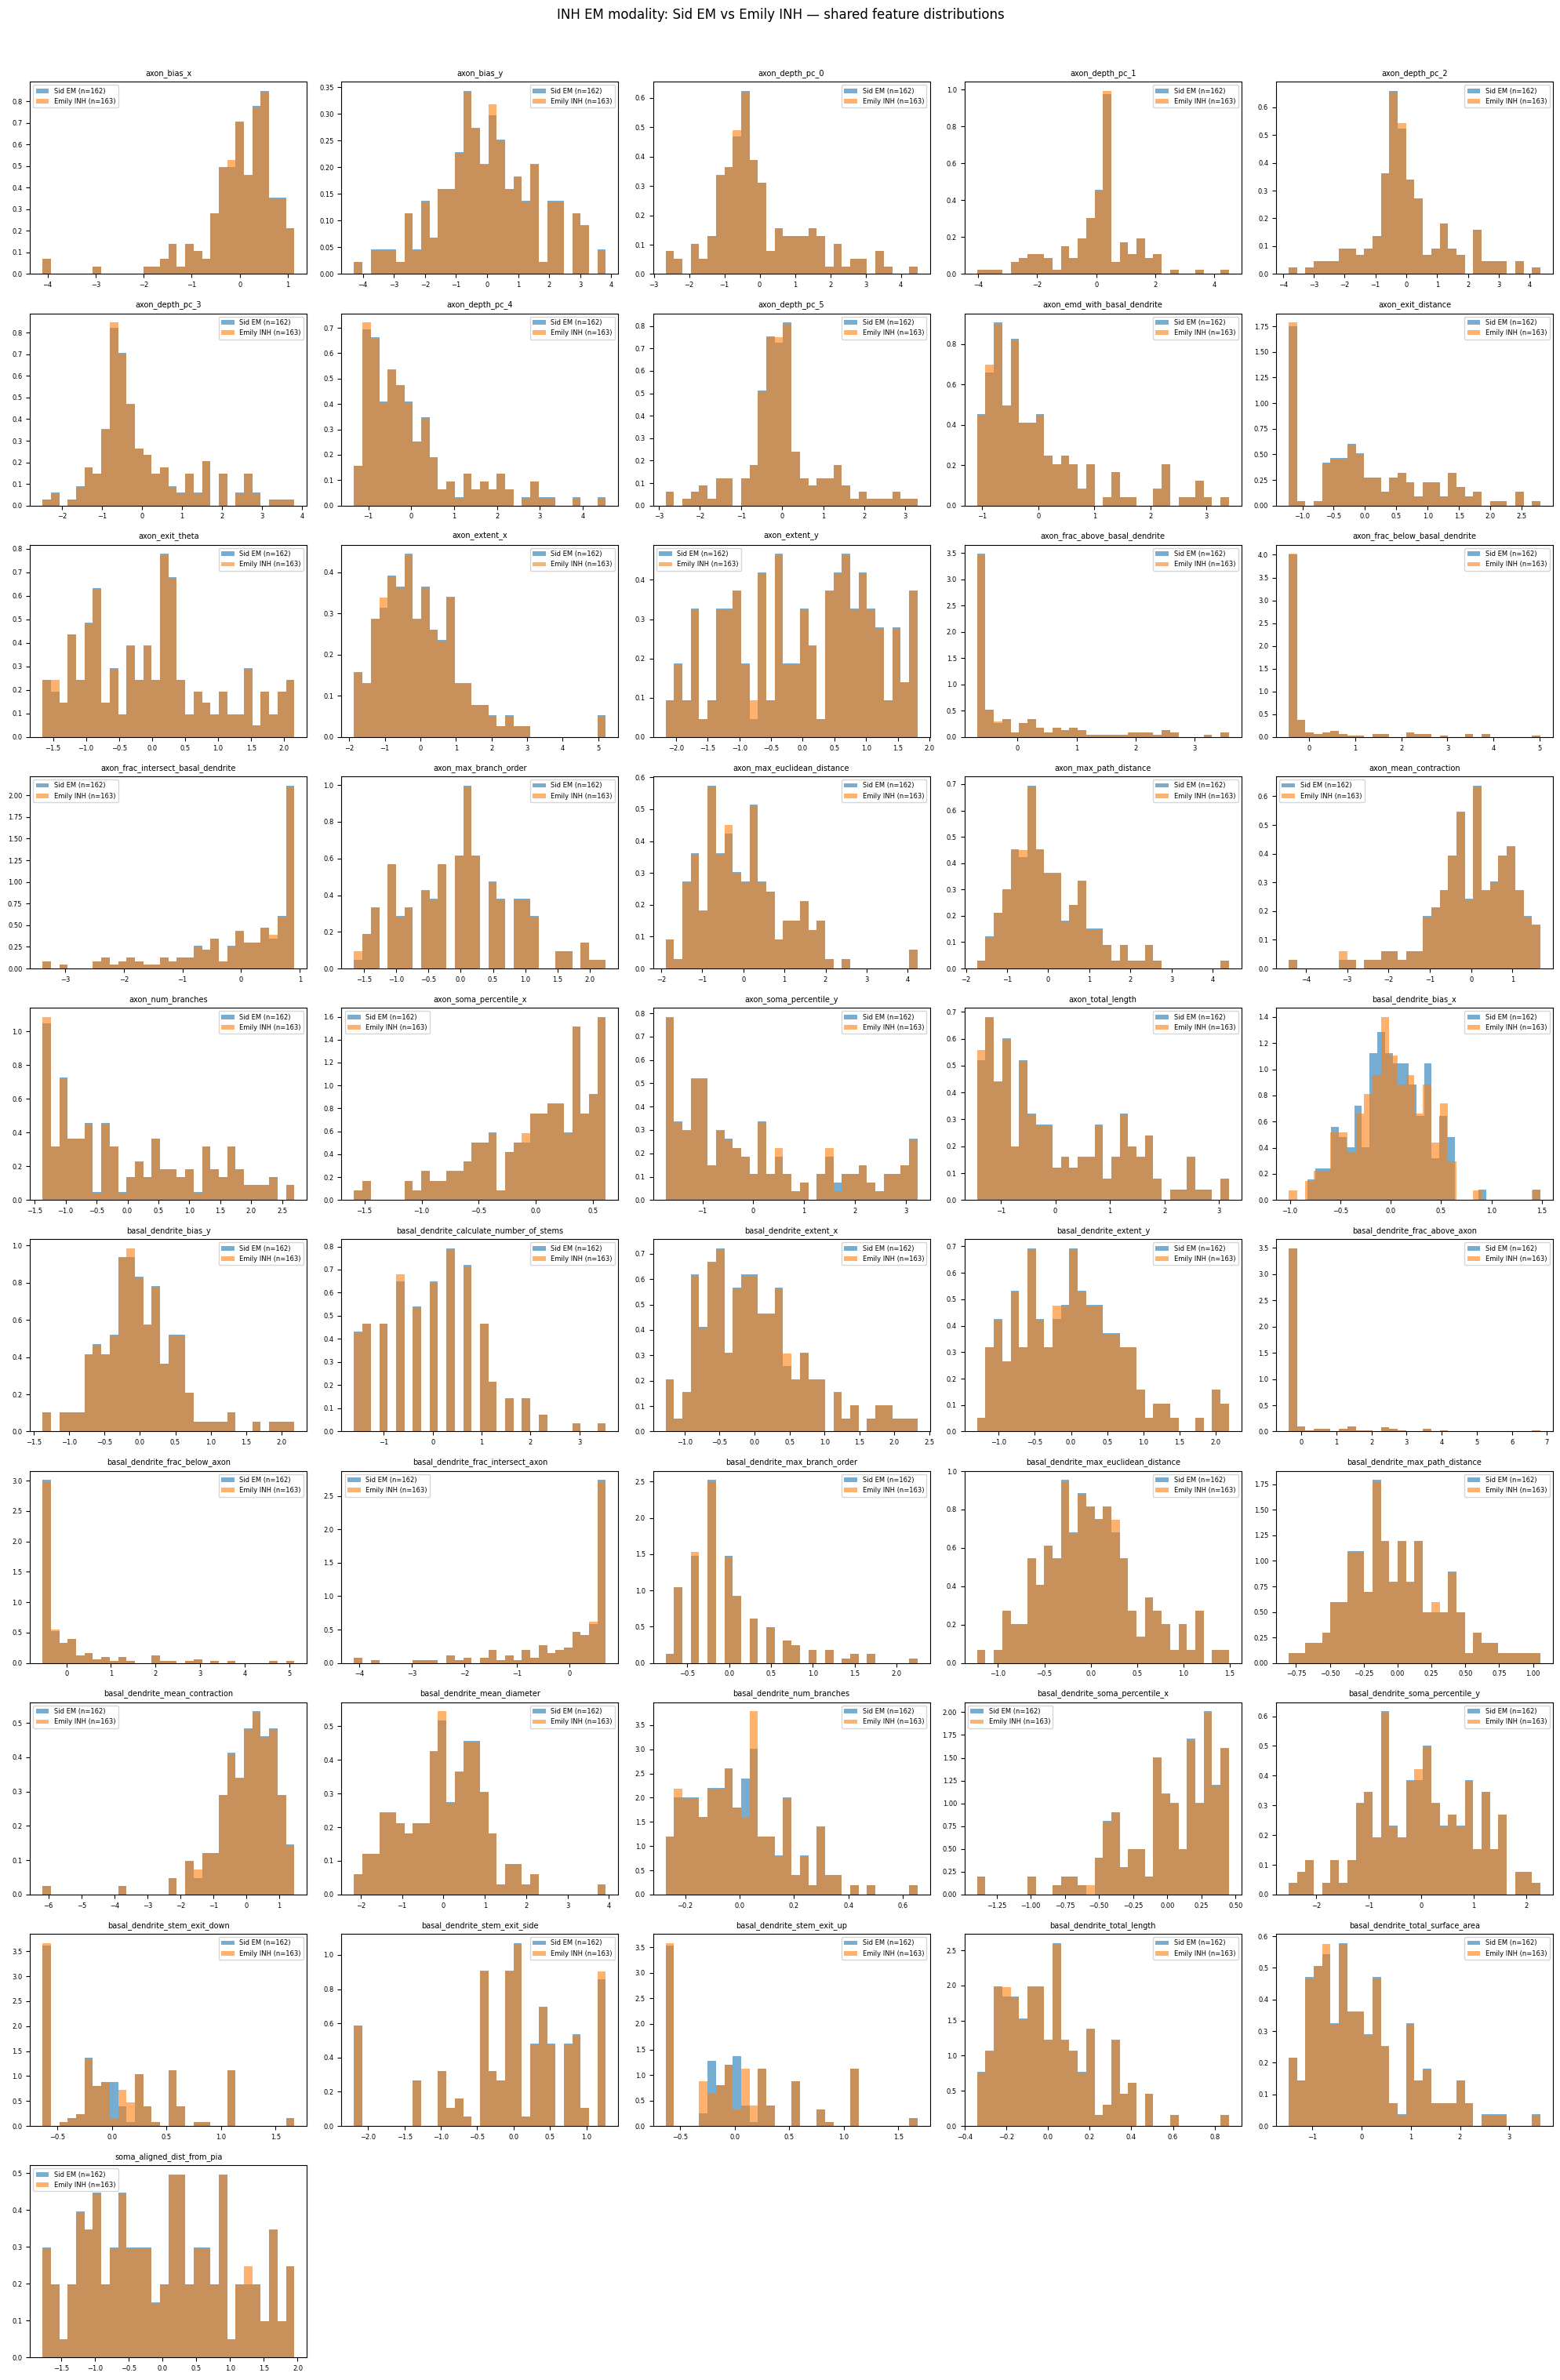

In [10]:
shared_inh_em = sorted(set(sid_inh_em_feat_cols) & set(emily_inh_feat_cols))
print(f"Shared INH EM features: {len(shared_inh_em)}")

ncols = 5
nrows = -(-len(shared_inh_em) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

for i, feat in enumerate(shared_inh_em):
    ax = axes[i]
    sid_vals   = df_sid_inh_em[feat].dropna()
    emily_vals = df_emily_inh[feat].dropna()
    ax.hist(sid_vals,   bins=30, alpha=0.6, label=f'Sid EM (n={len(sid_vals)})',   density=True)
    ax.hist(emily_vals, bins=30, alpha=0.6, label=f'Emily INH (n={len(emily_vals)})', density=True)
    ax.set_title(feat, fontsize=7)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=6)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('INH EM modality: Sid EM vs Emily INH — shared feature distributions', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 3B — INH PatchSeq modality: Sid PS vs existing `inh_morph_features` (shared morpho features)

Shared INH PatchSeq features: 46


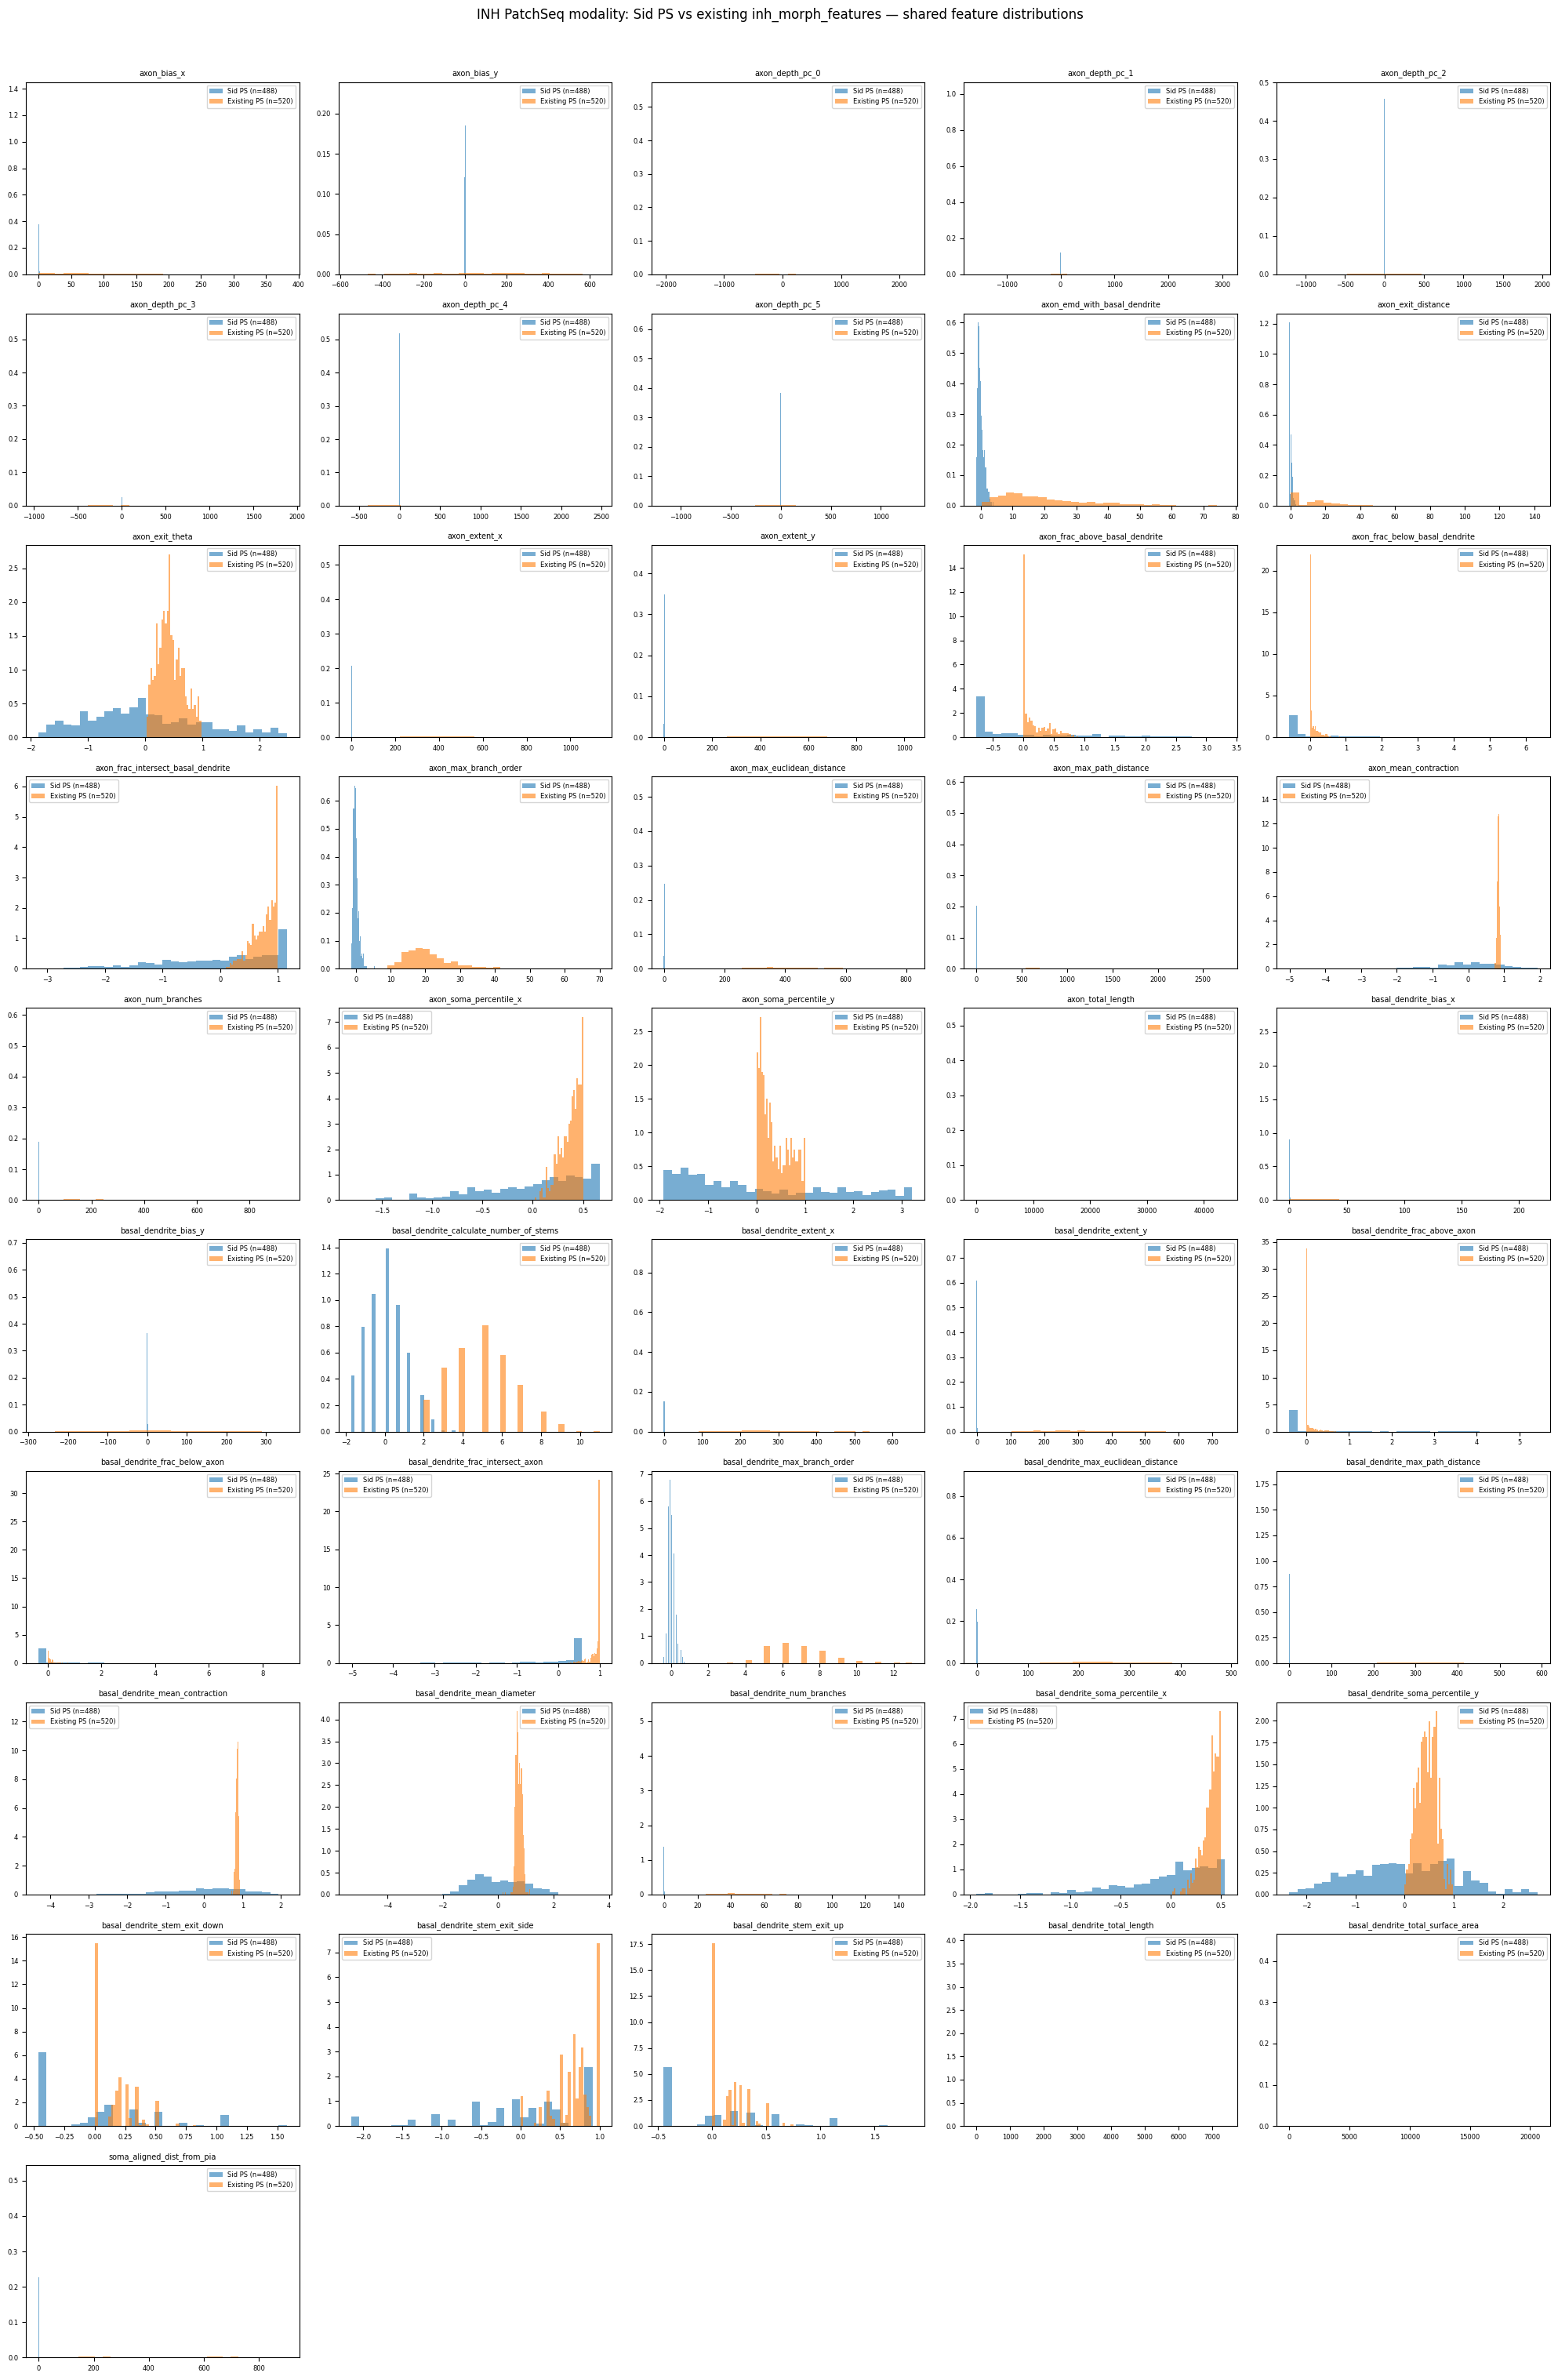

In [11]:
shared_inh_ps = sorted(set(sid_inh_ps_feat_cols) & set(existing_inh_ps_feat_cols))
print(f"Shared INH PatchSeq features: {len(shared_inh_ps)}")

ncols = 5
nrows = -(-len(shared_inh_ps) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

for i, feat in enumerate(shared_inh_ps):
    ax = axes[i]
    sid_vals      = df_sid_inh_ps[feat].dropna()
    existing_vals = df_inh_ps_existing[feat].dropna()
    ax.hist(sid_vals,      bins=30, alpha=0.6, label=f'Sid PS (n={len(sid_vals)})',           density=True)
    ax.hist(existing_vals, bins=30, alpha=0.6, label=f'Existing PS (n={len(existing_vals)})', density=True)
    ax.set_title(feat, fontsize=7)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=6)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('INH PatchSeq modality: Sid PS vs existing inh_morph_features — shared feature distributions', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


# Compare the labels
- INH: Sid's patchseq to existing patchseq (met type and t type)
- EXC: Matt's and umapknn results but needs mapping see below
```
met_to_descriptive_list = {
    # IT types — high confidence
    'IT-MET-1': 'L2/3 IT',
    'IT-MET-2': 'L4 IT',
    'IT-MET-3': 'L4/L5 IT',
    'IT-MET-4': 'L5 IT-1',
    'IT-MET-5': 'L5 IT-2',
    'IT-MET-6': 'L5 IT-3 Pld5',
    'IT-MET-7': 'L5/L6 IT Car3',
    'IT-MET-8': 'L6 IT-1',        # paper has L6 IT-1 and L6 IT-2;
                                    # second list has L6 IT-1, L6 IT-2, L6 IT-3
                                    # so one L6 IT in the second list has no MET match

    # PT/ET types — high confidence (PT = pyramidal tract = ET = extratelencephalic)
    'PT-MET-1': 'L5 ET-1 Chrna6',
    'PT-MET-2': 'L5 ET-2',
    'PT-MET-3': 'L5 ET-3',

    # NP — trivial
    'NP-MET-1': 'L5 NP',

    # CT — paper has 1, second list has 2
    'CT-MET-1': 'L6 CT-1',        # L6 CT-2 in second list has no MET match

    # L6b — paper has 3 subtypes, second list collapses to 1
    'L6b-MET-1': 'L6b',
    'L6b-MET-2': 'L6b',           # all three merge into single "L6b"
    'L6b-MET-3': 'L6b',
}
```

# Save to deltalakes LATER NOT NOW
Emily's data is already saved!